### 1. Importing Libraries

In [1]:
import numpy as np #math
import pandas as pd #dataframe
from matplotlib import pyplot as plt
import seaborn as sns

### 2. Importing and Exploration of the dataset

In [2]:
# loading the data

df = pd.read_csv('loans.csv',index_col=False)

In [3]:
# # showing the first 5 rows of the dataset:
df.head(10)

,client_id,loan_type,loan_amount,repaid,loan_id,loan_start,loan_end,rate
0,46109,home,13672,0,10243,2002-04-16,2003-12-20,2.15
1,46109,credit,9794,0,10984,2003-10-21,2005-07-17,1.25
2,46109,home,12734,1,10990,2006-02-01,2007-07-05,0.68
3,46109,cash,12518,1,10596,2010-12-08,2013-05-05,1.24
4,46109,credit,14049,1,11415,2010-07-07,2012-05-21,3.13
5,46109,home,6935,0,11501,2006-09-17,2008-11-26,1.94
6,46109,cash,6177,1,11141,2007-03-12,2009-04-26,9.48
7,46109,home,12656,0,11658,2006-05-26,2007-10-15,4.14
8,46109,home,11062,1,11611,2012-09-12,2014-03-14,5.48
9,46109,other,4050,1,10828,2003-12-06,2005-08-19,4.26


In [4]:
# To check the Dimensions of the dataset:
df.shape

(443, 8)

In [5]:
# Checking the info of the data:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 443 entries, 0 to 442
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   client_id    443 non-null    int64  
 1   loan_type    443 non-null    object 
 2   loan_amount  443 non-null    int64  
 3   repaid       443 non-null    int64  
 4   loan_id      443 non-null    int64  
 5   loan_start   443 non-null    object 
 6   loan_end     443 non-null    object 
 7   rate         443 non-null    float64
dtypes: float64(1), int64(4), object(3)
memory usage: 27.8+ KB


In [6]:
df['loan_amount'].mean()

np.float64(7982.31151241535)

### 3.Filtering Data

Example: filter high loan amounts

In [7]:
high_loan= df[df['loan_amount']> df['loan_amount'].mean()]

high_loan.head()


,client_id,loan_type,loan_amount,repaid,loan_id,loan_start,loan_end,rate
0,46109,home,13672,0,10243,2002-04-16,2003-12-20,2.15
1,46109,credit,9794,0,10984,2003-10-21,2005-07-17,1.25
2,46109,home,12734,1,10990,2006-02-01,2007-07-05,0.68
3,46109,cash,12518,1,10596,2010-12-08,2013-05-05,1.24
4,46109,credit,14049,1,11415,2010-07-07,2012-05-21,3.13


### 4. Converting the data types of columns

    - loan_id to object
    - repaid to category dtype
    - loan_start and loan_end to date type

In [8]:
df.dtypes

,0
client_id,int64
loan_type,object
loan_amount,int64
repaid,int64
loan_id,int64
loan_start,object
loan_end,object
rate,float64


In [9]:
df['loan_id']=df['loan_id'].astype('object') #int to object

df['repaid']=df['repaid'].astype('category') #int to object



In [10]:
df['loan_start']=pd.to_datetime(df['loan_start'],format='%Y-%m-%d')


df['loan_end']=pd.to_datetime(df['loan_end'],format='%Y-%m-%d')


df.head()

,client_id,loan_type,loan_amount,repaid,loan_id,loan_start,loan_end,rate
0,46109,home,13672,0,10243,2002-04-16,2003-12-20,2.15
1,46109,credit,9794,0,10984,2003-10-21,2005-07-17,1.25
2,46109,home,12734,1,10990,2006-02-01,2007-07-05,0.68
3,46109,cash,12518,1,10596,2010-12-08,2013-05-05,1.24
4,46109,credit,14049,1,11415,2010-07-07,2012-05-21,3.13


#### Checking the datatypes again:

In [11]:
df.dtypes

,0
client_id,int64
loan_type,object
loan_amount,int64
repaid,category
loan_id,object
loan_start,datetime64[ns]
loan_end,datetime64[ns]
rate,float64


In [12]:
df.describe()

,client_id,loan_amount,loan_start,loan_end,rate
count,443.000000,443.000000,443,443,443.000000
mean,38911.060948,7982.311512,2007-08-02 12:56:53.092550912,2009-08-23 11:35:37.246049536,3.217156
min,25707.000000,559.000000,2000-01-26 00:00:00,2001-08-02 00:00:00,0.010000
25%,32885.000000,4232.500000,2003-10-19 00:00:00,2005-09-12 12:00:00,1.220000
50%,39505.000000,8320.000000,2007-03-10 00:00:00,2009-03-19 00:00:00,2.780000
75%,46109.000000,11739.000000,2011-07-31 00:00:00,2013-09-11 12:00:00,4.750000
max,49624.000000,14971.000000,2014-11-11 00:00:00,2017-05-07 00:00:00,12.620000
std,7768.681063,4172.891992,NaN,NaN,2.397168


In [13]:
q1= df['loan_amount'].quantile(0.25)
q3=df['loan_amount'].quantile(0.75)

IQR=q3-q1

lower_bound=q1-1.5*IQR
Upper_bound=q3+1.5*IQR


outliers= df[(df['loan_amount']<lower_bound)|(df['loan_amount']>Upper_bound)]

print(outliers)

Empty DataFrame
Columns: [client_id, loan_type, loan_amount, repaid, loan_id, loan_start, loan_end, rate]
Index: []


### 5. Summary Statistics of the data

In [14]:
# Numerical summary
summary_stats = df.describe()
print(summary_stats)

# Categorical summary
categorical_summary = df.describe(include='object')
print(categorical_summary)


          client_id   loan_amount                     loan_start  \
count    443.000000    443.000000                            443   
mean   38911.060948   7982.311512  2007-08-02 12:56:53.092550912   
min    25707.000000    559.000000            2000-01-26 00:00:00   
25%    32885.000000   4232.500000            2003-10-19 00:00:00   
50%    39505.000000   8320.000000            2007-03-10 00:00:00   
75%    46109.000000  11739.000000            2011-07-31 00:00:00   
max    49624.000000  14971.000000            2014-11-11 00:00:00   
std     7768.681063   4172.891992                            NaN   

                            loan_end        rate  
count                            443  443.000000  
mean   2009-08-23 11:35:37.246049536    3.217156  
min              2001-08-02 00:00:00    0.010000  
25%              2005-09-12 12:00:00    1.220000  
50%              2009-03-19 00:00:00    2.780000  
75%              2013-09-11 12:00:00    4.750000  
max              2017-05-07 00

### 6. Missing Values

In [15]:
# use isnull().sum() to check for missing values
df.isnull().sum()

,0
client_id,0
loan_type,0
loan_amount,0
repaid,0
loan_id,0
loan_start,0
loan_end,0
rate,0


### 7.Filtering Data (Focus on Trends)

Example: filter high loan amounts

In [16]:
high_loans = df[df['loan_amount'] > df['loan_amount'].mean()]
print(high_loans.head())


   client_id loan_type  loan_amount repaid loan_id loan_start   loan_end  rate
0      46109      home        13672      0   10243 2002-04-16 2003-12-20  2.15
1      46109    credit         9794      0   10984 2003-10-21 2005-07-17  1.25
2      46109      home        12734      1   10990 2006-02-01 2007-07-05  0.68
3      46109      cash        12518      1   10596 2010-12-08 2013-05-05  1.24
4      46109    credit        14049      1   11415 2010-07-07 2012-05-21  3.13


### 8.Grouping Data (Pattern Discovery)

Identify trends across categories

In [17]:
loan_by_type = df.groupby('loan_type')['loan_amount'].mean()
print(loan_by_type)


loan_type
cash      8098.000000
credit    7429.084112
home      8009.347107
other     8388.196262
Name: loan_amount, dtype: float64


### 9. Outliers Treatment

To check for the presence of outliers, we plot Boxplot.

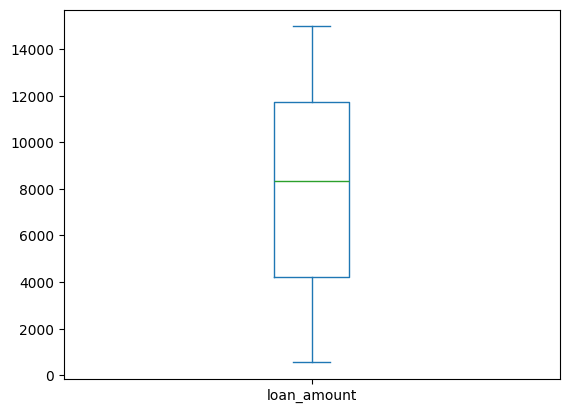

In [18]:
# For loan_amount
df['loan_amount'].plot(kind='box')
plt.show()

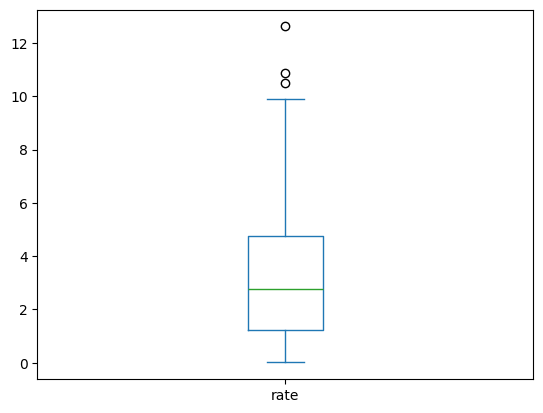

In [19]:
# For rate
df['rate'].plot(kind='box')
plt.show()

### 10.Correlation Analysis

Find relationships between numerical variables

In [20]:
# Select numeric columns only
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Correlation matrix
correlation_matrix = numeric_df.corr()
print(correlation_matrix)


             client_id  loan_amount      rate
client_id     1.000000     0.046507  0.058672
loan_amount   0.046507     1.000000 -0.033340
rate          0.058672    -0.033340  1.000000


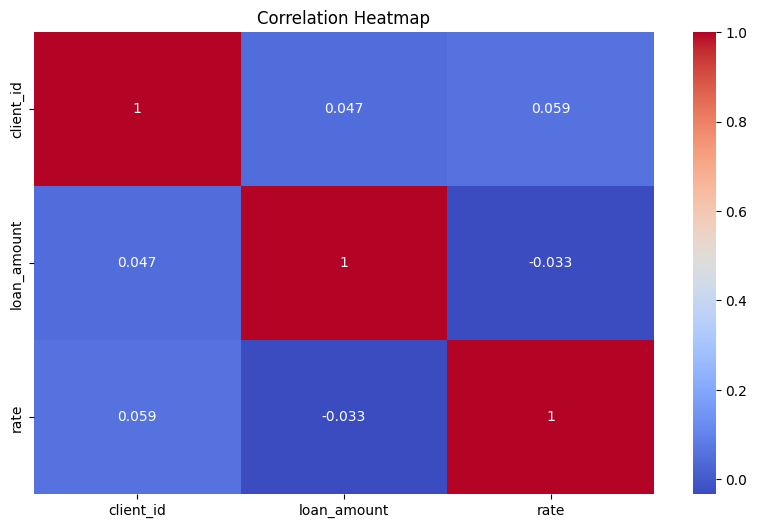

In [21]:
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


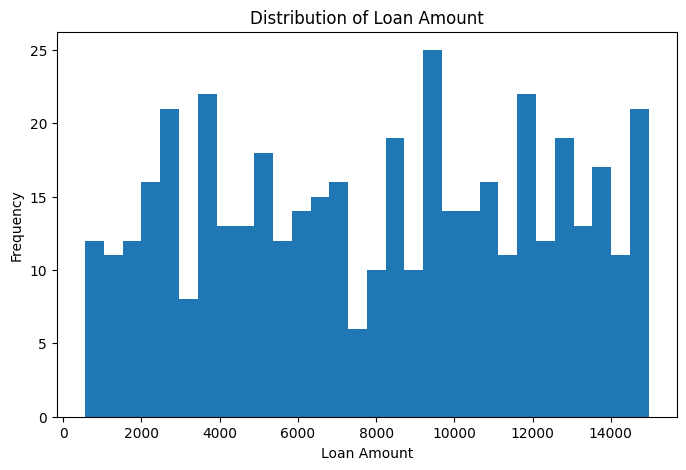

In [22]:
plt.figure(figsize=(8, 5))
plt.hist(df['loan_amount'], bins=30)
plt.xlabel('Loan Amount')
plt.ylabel('Frequency')
plt.title('Distribution of Loan Amount')
plt.show()

In [23]:
%pip install ydata-profiling
from ydata_profiling import ProfileReport

profile = ProfileReport(df, title="Loan Data Report")
profile.to_file("loan_data_report.html")
profile

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 25.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 61.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 45.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 7.1 MB/s eta 0:00:00


/tmp/ipykernel_3221/3069074823.py:2: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 8/8 [00:00<00:00, 73.81it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]